### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

In [3]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [117]:
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso, Ridge, LinearRegression

In [5]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [6]:
df = pd.read_csv('./data/StoreDemand.csv')

In [7]:
df.shape

(913000, 4)

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


### Step 3: Exploaring Data

#### Basic Info

In [12]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [13]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum() / len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [14]:
feature_info

,null,null(%),unique,type
date,0,0.0,1826,datetime64[ns]
store,0,0.0,10,int64
item,0,0.0,50,int64
sales,0,0.0,213,int64


#### Target Distribution

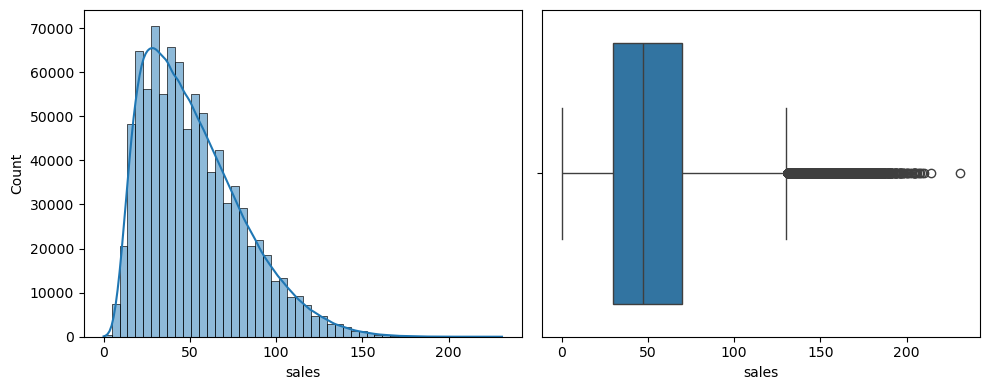

In [36]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(x='sales', data=df, bins=50, kde=True)
plt.subplot(1, 2, 2)
sns.boxplot(x='sales', data=df, orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

#### Create Feature

In [23]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [34]:
df['weekend'] = df['date'].dt.weekday.map(lambda x: 1 if x>4 else 0)
df['weekday'] = df['date'].dt.weekday

In [32]:
india_holiday = holidays.country_holidays('IN')
df['holidays'] = df['date'].map(lambda x: 1 if india_holiday.get(x) else 0)

In [33]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))

In [37]:
features_cols = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

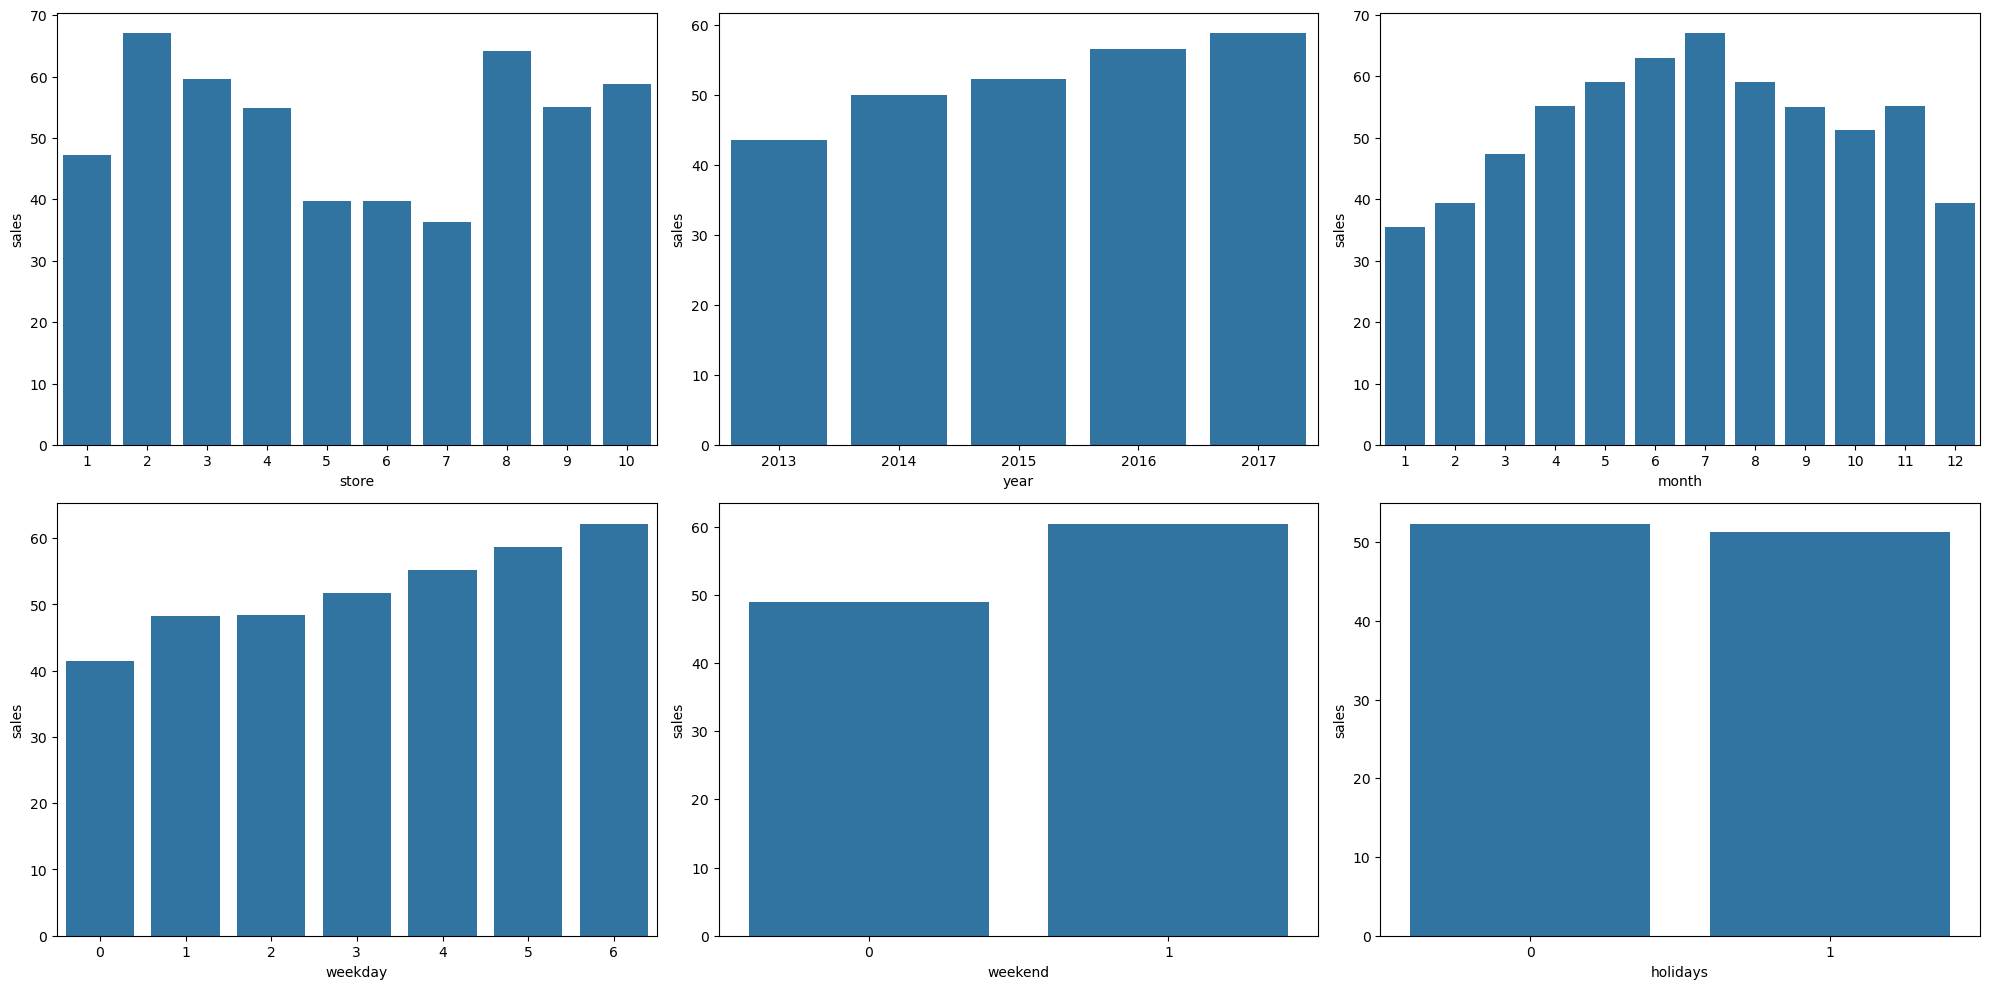

In [39]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(features_cols):
    plt.subplot(2, 3, i+1)
    sns.barplot(x=col, y='sales', data=df, errorbar=None)
plt.tight_layout()

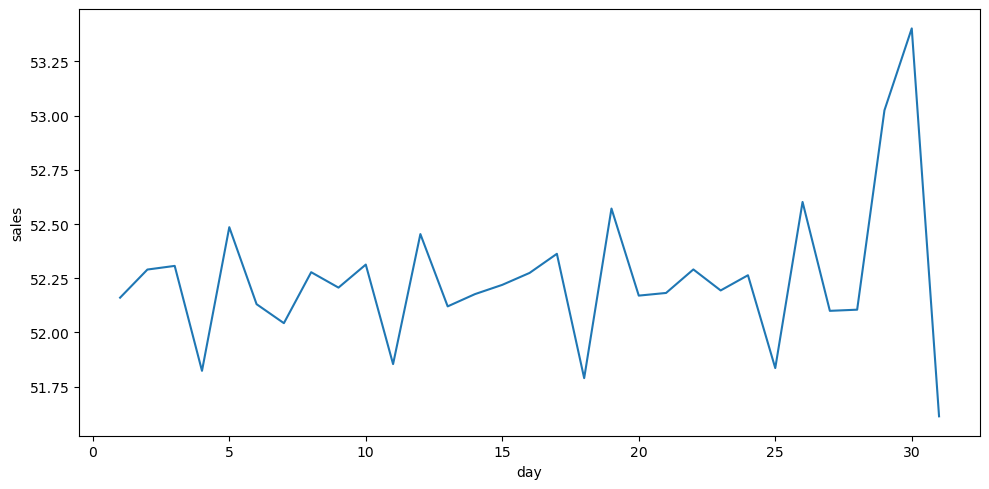

In [42]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='day', y='sales', data=df, errorbar=None)
plt.tight_layout()

In [62]:
window_size = 30
temp = df[df['year'] == 2013]
temp = temp.groupby('date')['sales'].mean()
windows = temp.rolling(window_size)
sma = windows.mean()[window_size-1:]

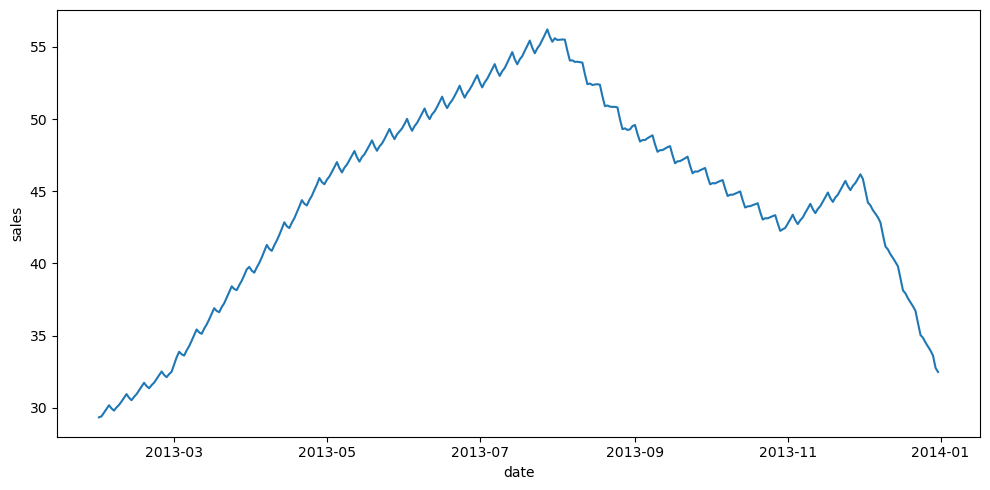

In [67]:
plt.figure(figsize=(10, 5))
sns.lineplot(sma, errorbar=None)
plt.tight_layout()

#### Deal Outliers

In [87]:
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [89]:
lower, upper = find_outliers_iqr(df['sales'])

In [94]:
df = df[df['sales'] < upper].reset_index(drop=True)

#### Heat Map

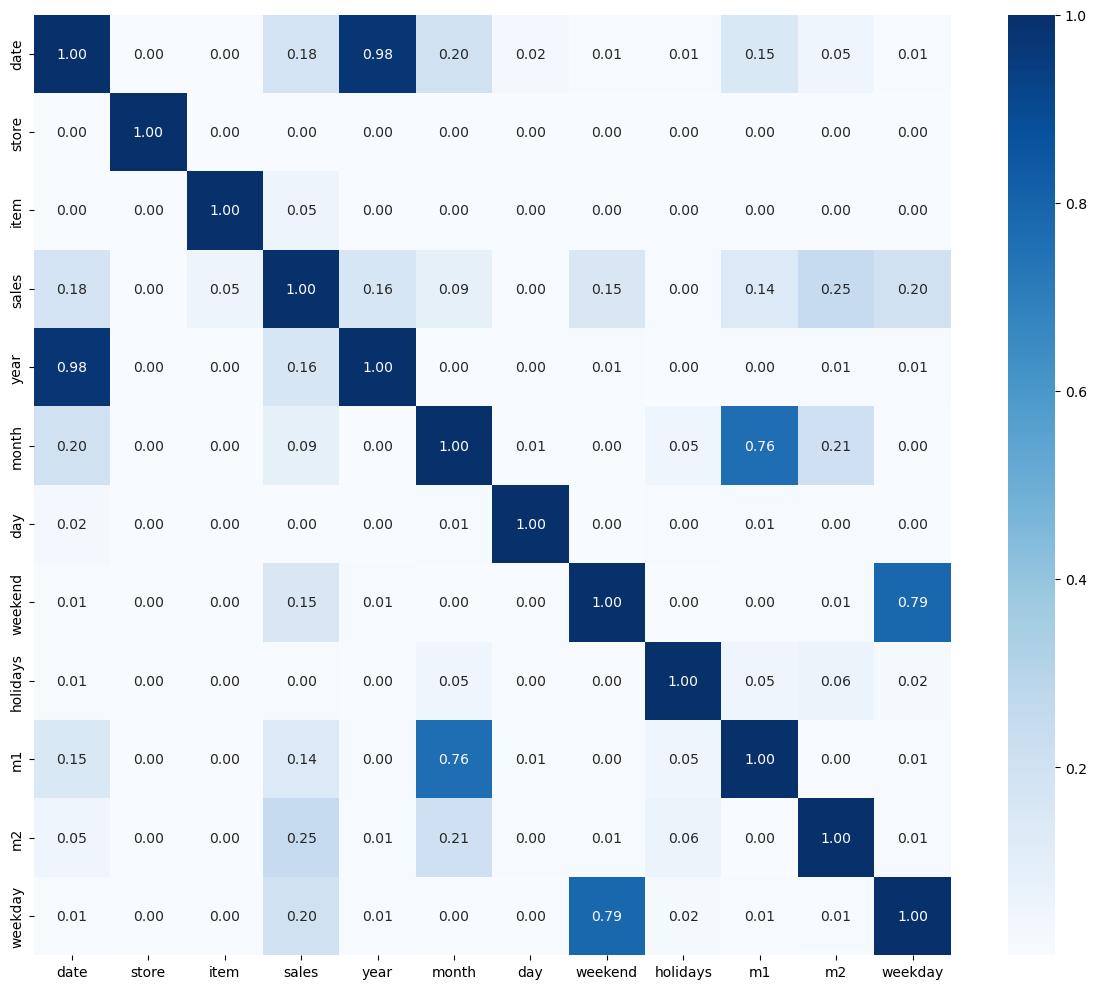

In [97]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [98]:
features = df.drop(['date', 'sales'], axis=1)
target = df['sales']

In [99]:
raw_features = features.columns.to_list()

In [100]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [101]:
features = selector.fit_transform(features, target)

In [102]:
deal_features = features.columns.to_list()

In [103]:
delet_features = list(set(raw_features) - set(deal_features))

In [104]:
print('raw features:', raw_features)
print('deal features:', deal_features)
print('delete features:', delet_features)

raw features: ['store', 'item', 'year', 'month', 'day', 'weekend', 'holidays', 'm1', 'm2', 'weekday']
deal features: ['store', 'item', 'year', 'month', 'day', 'weekend', 'holidays', 'm1', 'm2', 'weekday']
delete features: []


#### Split Data

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [106]:
scaler = StandardScaler()

In [107]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [118]:
models = [
    LinearRegression(),
    XGBRegressor(),
    Lasso(),
    Ridge()
]

In [119]:
for model in models:
    print('-'*20, 'model:', model.__class__.__name__, '-'*20)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        error_score='raise'
    )
    print('training mae scores:', [round(-1*x, 3) for x in scores])
    print('training mae score:', round(-1*scores.mean(), 3))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print('testing mae score', round(metrics.mean_absolute_error(y_test, y_pred), 3))

-------------------- model: LinearRegression --------------------
training mae scores: [20.191, 20.183, 20.225, 20.199, 20.251]
training mae score: 20.21
testing mae score 20.214
-------------------- model: XGBRegressor --------------------
training mae scores: [5.841, 5.849, 5.839, 5.852, 5.857]
training mae score: 5.848
testing mae score 5.887
-------------------- model: Lasso --------------------
training mae scores: [20.338, 20.335, 20.36, 20.332, 20.384]
training mae score: 20.35
testing mae score 20.358
-------------------- model: Ridge --------------------
training mae scores: [20.191, 20.183, 20.225, 20.199, 20.251]
training mae score: 20.21
testing mae score 20.214
